# MinTrace Baseline with Train/Test Split

This notebook demonstrates a complete workflow:
1. Loading TourismSmall data
2. Splitting into Train and Test sets
3. Generating Base Forecasts (AutoARIMA)
4. Reconciling with MinTrace
5. Evaluating Performance (MSE)

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, Naive
from hierarchicalforecast.core import HierarchicalReconciliation
from hierarchicalforecast.methods import MinTrace
# Import evaluate directly
from hierarchicalforecast.evaluation import evaluate
from hierarchicalforecast.utils import HierarchicalPlot
from datasetsforecast.hierarchical import HierarchicalData
from utilsforecast.losses import mse, rmse, mape

## 1. Load Data & Split

In [3]:
# Load TourismSmall dataset
Y_df, S_df, tags = HierarchicalData.load('./data', 'TourismSmall')
Y_df['ds'] = pd.to_datetime(Y_df['ds'])
S_df = S_df.reset_index(names="unique_id")

# split train/test sets
Y_test_df  = Y_df.groupby('unique_id').tail(4)
Y_train_df = Y_df.drop(Y_test_df.index)

print("Train size:", len(Y_train_df))
print("Test size:", len(Y_test_df))
display(Y_train_df.head())

Train size: 2848
Test size: 356


,unique_id,ds,y
0,total,1998-03-31,84503
1,total,1998-06-30,65312
2,total,1998-09-30,72753
3,total,1998-12-31,70880
4,total,1999-03-31,86893


## 2. Base Forecasts

In [4]:
# Compute base auto-ARIMA predictions
# Ensure frequency matches dataset (Quarter End 'QE')
fcst = StatsForecast(models=[AutoARIMA(season_length=4)],
                     freq='QE', n_jobs=-1)

Y_hat_df = fcst.forecast(df=Y_train_df, h=4, fitted=True)
Y_fitted_df = fcst.forecast_fitted_values()

display(Y_fitted_df.head())

,unique_id,ds,y,AutoARIMA
0,bus,1998-03-31,9815.0,9805.138672
1,bus,1998-06-30,11823.0,11811.083984
2,bus,1998-09-30,13565.0,13551.294922
3,bus,1998-12-31,11478.0,11466.335938
4,bus,1999-03-31,10027.0,9705.829102


In [5]:
Y_hat_df.unique_id.unique()

array(['bus', 'hol', 'nsw-bus', 'nsw-bus-city', 'nsw-bus-noncity',
       'nsw-hol', 'nsw-hol-city', 'nsw-hol-noncity', 'nsw-oth',
       'nsw-oth-city', 'nsw-oth-noncity', 'nsw-vfr', 'nsw-vfr-city',
       'nsw-vfr-noncity', 'nt-bus', 'nt-bus-city', 'nt-bus-noncity',
       'nt-hol', 'nt-hol-city', 'nt-hol-noncity', 'nt-oth', 'nt-oth-city',
       'nt-oth-noncity', 'nt-vfr', 'nt-vfr-city', 'nt-vfr-noncity', 'oth',
       'qld-bus', 'qld-bus-city', 'qld-bus-noncity', 'qld-hol',
       'qld-hol-city', 'qld-hol-noncity', 'qld-oth', 'qld-oth-city',
       'qld-oth-noncity', 'qld-vfr', 'qld-vfr-city', 'qld-vfr-noncity',
       'sa-bus', 'sa-bus-city', 'sa-bus-noncity', 'sa-hol', 'sa-hol-city',
       'sa-hol-noncity', 'sa-oth', 'sa-oth-city', 'sa-oth-noncity',
       'sa-vfr', 'sa-vfr-city', 'sa-vfr-noncity', 'tas-bus',
       'tas-bus-city', 'tas-bus-noncity', 'tas-hol', 'tas-hol-city',
       'tas-hol-noncity', 'tas-oth', 'tas-oth-city', 'tas-oth-noncity',
       'tas-vfr', 'tas-vfr-city

## 3. Reconciliation (MinTrace)

In [6]:
# Reconcile the base predictions
reconcilers = [
    # MinTrace(method='ols'),
    # MinTrace(method='wls_struct'),
    MinTrace(method='mint_shrink')
]
hrec = HierarchicalReconciliation(reconcilers=reconcilers)

Y_rec_df = hrec.reconcile(Y_hat_df=Y_hat_df, Y_df=Y_fitted_df,
                              S=S_df, tags=tags)

display(Y_rec_df.head())

C:\Users\MarcellNemeth\AppData\Local\Temp\ipykernel_11096\668890071.py:9: DeprecationWarning: The 'S' parameter is deprecated and will be removed in a future version. Please use 'S_df' instead.
  Y_rec_df = hrec.reconcile(Y_hat_df=Y_hat_df, Y_df=Y_fitted_df,


,unique_id,ds,AutoARIMA,AutoARIMA/MinTrace_method-mint_shrink
0,total,2006-03-31,85909.171875,82803.807934
1,total,2006-06-30,63981.953125,62433.835391
2,total,2006-09-30,70983.882812,68018.710930
3,total,2006-12-31,67429.898438,65955.846199
4,hol,2006-03-31,42805.343750,42604.259122


## 4. Evaluation

In [7]:
# Combine reconciled forecasts with test data
# Ensure data types match for merge
Y_rec_df['ds'] = pd.to_datetime(Y_rec_df['ds'])
Y_test_df['ds'] = pd.to_datetime(Y_test_df['ds'])

df = Y_rec_df.merge(Y_test_df, on=['unique_id', 'ds'])

print(f"Merged DataFrame size: {len(df)}")
if len(df) == 0:
    print("WARNING: Empty merge. Checking dates...")
    print("Forecast Dates:", Y_rec_df['ds'].unique())
    print("Test Dates:", Y_test_df['ds'].unique())

# Evaluate using the standalone evaluate function
evaluation_df = evaluate(df=df,
                      tags=tags,
                      metrics=[rmse],
                      benchmark="AutoARIMA")

display(evaluation_df)

Merged DataFrame size: 356


C:\Users\MarcellNemeth\AppData\Local\Temp\ipykernel_11096\3525774734.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Y_test_df['ds'] = pd.to_datetime(Y_test_df['ds'])


,level,metric,AutoARIMA,AutoARIMA/MinTrace_method-mint_shrink
0,Country,rmse-scaled,1.0,0.900613
1,Country/Purpose,rmse-scaled,1.0,0.783328
2,Country/Purpose/State,rmse-scaled,1.0,0.934927
3,Country/Purpose/State/CityNonCity,rmse-scaled,1.0,1.039071
4,Overall,rmse-scaled,1.0,0.933561


## 5. Visualization

We use `HierarchicalPlot` to visualize the history, truth (test set), and forecasts (Base + MinTrace).

Plotting models: ['y', 'AutoARIMA', 'AutoARIMA/MinTrace_method-mint_shrink']


<Figure size 700x600 with 0 Axes>

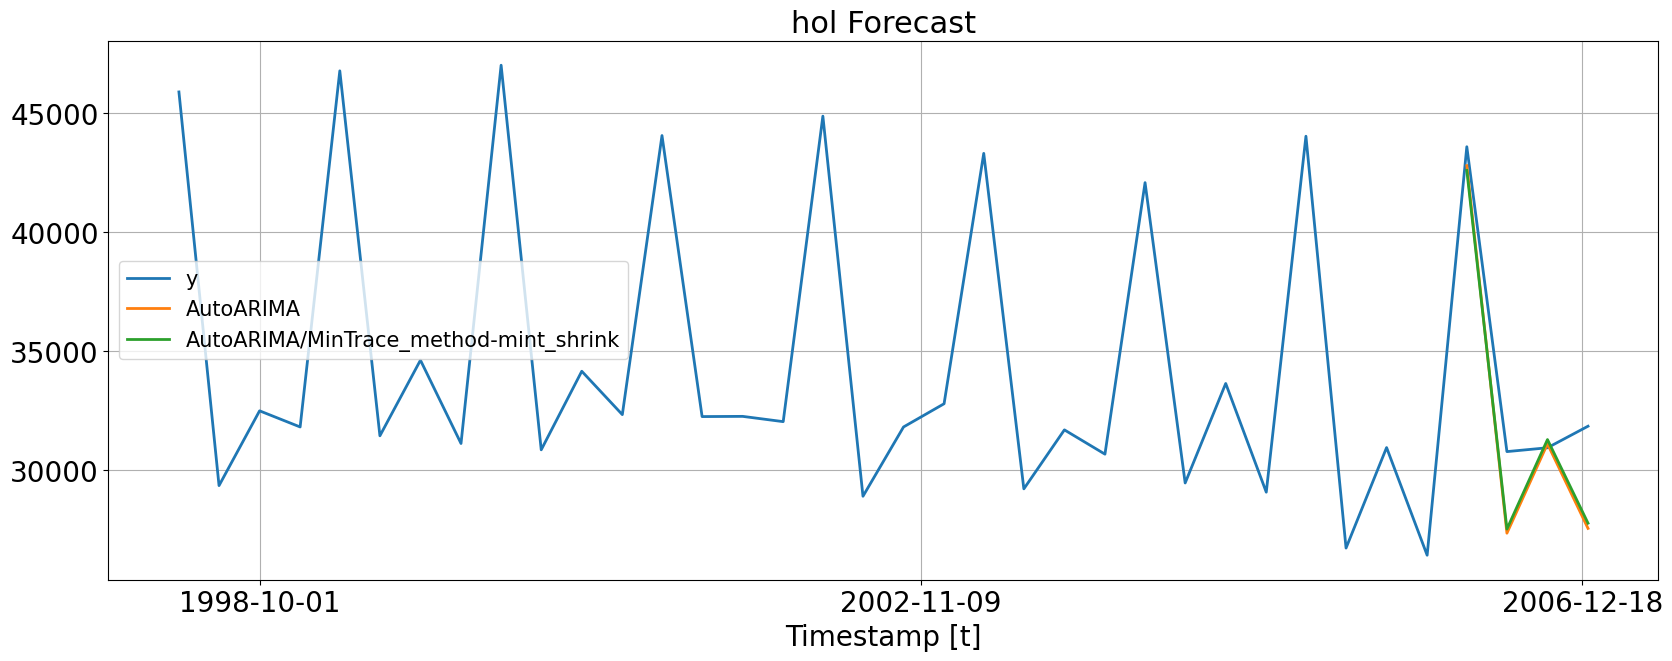

In [8]:
# Prepare DataFrame for plotting
# We combine Training History + Test Set (Truth) + Forecasts
# 1. Get full history (Train + Test) from Y_df
plot_df = Y_df.set_index(['unique_id', 'ds']).copy()

# 2. Join with Forecasts (Y_rec_df), keeping all columns
plot_rec_df = Y_rec_df.set_index(['unique_id', 'ds'])
plot_df = plot_df.join(plot_rec_df, how='outer').reset_index()

# Initialize HierarchicalPlot
# Ensure S_df has unique_id as a column
S_df_plot = S_df.reset_index(names='unique_id') if 'unique_id' not in S_df.columns else S_df

hplot = HierarchicalPlot(S=S_df_plot, tags=tags)

# Plot specific series (e.g., Total aggregate)
# We plot 'y' (History+Truth), 'AutoARIMA' (Base), and 'AutoARIMA/MinTrace_method-mint_shrink' (Reconciled)
models_to_plot = ['y', 'AutoARIMA']
mint_col = [c for c in plot_df.columns if 'MinTrace' in c]
# if mint_col:
# add all mint_col to models_to_plot
models_to_plot.extend(mint_col)

print(f"Plotting models: {models_to_plot}")

plt.figure(figsize=(7, 6))
# Note: The dataset uses 'total' (lowercase) not 'Total'
hplot.plot_series(
    series='hol', 
    Y_df=plot_df, 
    models=models_to_plot
)

plt.show()

In [9]:
plot_df.unique_id.unique()

array(['bus', 'hol', 'nsw-bus', 'nsw-bus-city', 'nsw-bus-noncity',
       'nsw-hol', 'nsw-hol-city', 'nsw-hol-noncity', 'nsw-oth',
       'nsw-oth-city', 'nsw-oth-noncity', 'nsw-vfr', 'nsw-vfr-city',
       'nsw-vfr-noncity', 'nt-bus', 'nt-bus-city', 'nt-bus-noncity',
       'nt-hol', 'nt-hol-city', 'nt-hol-noncity', 'nt-oth', 'nt-oth-city',
       'nt-oth-noncity', 'nt-vfr', 'nt-vfr-city', 'nt-vfr-noncity', 'oth',
       'qld-bus', 'qld-bus-city', 'qld-bus-noncity', 'qld-hol',
       'qld-hol-city', 'qld-hol-noncity', 'qld-oth', 'qld-oth-city',
       'qld-oth-noncity', 'qld-vfr', 'qld-vfr-city', 'qld-vfr-noncity',
       'sa-bus', 'sa-bus-city', 'sa-bus-noncity', 'sa-hol', 'sa-hol-city',
       'sa-hol-noncity', 'sa-oth', 'sa-oth-city', 'sa-oth-noncity',
       'sa-vfr', 'sa-vfr-city', 'sa-vfr-noncity', 'tas-bus',
       'tas-bus-city', 'tas-bus-noncity', 'tas-hol', 'tas-hol-city',
       'tas-hol-noncity', 'tas-oth', 'tas-oth-city', 'tas-oth-noncity',
       'tas-vfr', 'tas-vfr-city

## 6. Access and Visualize the MinT Shrink Covariance Matrix

Here we access the estimated covariance matrix `W` from the reconciler object and visualize it.

In [10]:
# Access the MinTrace object (it's the first reconciler in the list)
mint_reconciler = hrec.reconcilers[0]

# The estimated covariance matrix is stored in .W
W_matrix = mint_reconciler.W

print("Covariance Matrix Shape:", W_matrix.shape)
print("Sample of Covariance Matrix:\n", W_matrix[:5, :5])

Covariance Matrix Shape: (89, 89)
Sample of Covariance Matrix:
 [[ 9.22689807e+06  6.86953629e+05  6.73237219e+05  2.89356477e+05
   1.69639910e+05]
 [ 6.86953629e+05  2.04396307e+06  8.06591832e+04 -3.90949422e+02
   8.40042018e+04]
 [ 6.73237219e+05  8.06591832e+04  2.45012659e+06  1.38838152e+05
  -4.48010545e+04]
 [ 2.89356477e+05 -3.90949422e+02  1.38838152e+05  6.01073282e+05
  -3.63788727e+03]
 [ 1.69639910e+05  8.40042018e+04 -4.48010545e+04 -3.63788727e+03
   4.58167108e+05]]


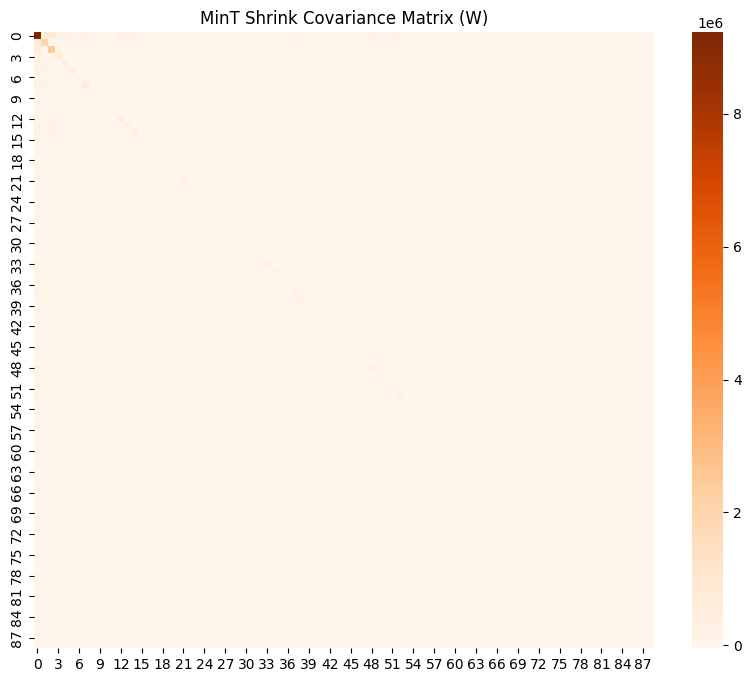

In [13]:
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(W_matrix, cmap='Oranges')
plt.title('MinT Shrink Covariance Matrix (W)')
plt.show()